# Week 8 — Economic Models — Neoclassical Growth via Value Function Iteration

**Programming and Numerical Methods for Economics (ECNM10115)** · The University of Edinburgh

**Learning goals.** Solving the deterministic neoclassical growth model by value function iteration — the workhorse method of modern macro.

> **How to work through this notebook:** run every cell in order (`Shift+Enter`). When you reach a result, pause and predict it before running — that habit is what turns reading into learning. Experiment: change parameters, break things, re-run.


# Neoclassical Growth Model: Deterministic
We have the recursive formulation
\begin{equation}
    \begin{aligned}
        v(k) =&
            \max_{c, k'} && u(c) + \beta v(k') \\ 
        & \text{s.t. }
            && c + k' \leq A k^\alpha + (1-\delta) k
    \end{aligned}
\end{equation}

First, let's code up our VFI solution algorithm.  We split it into two steps:
1. An update step, where we re-solve the maximization problem
2. An outer loop, where we repeatedly call step 1, and check for convergence

In [5]:
# First some package housekeeping -- make sure our environment is activated
using Pkg 
Pkg.activate(@__DIR__)
# Pkg.instantiate()

# Load packages
using Parameters
using QuantEcon
using Plots
using Format


  Activating new project at `C:\Users\jzurita\OneDrive - University of Edinburgh\Courses\Programming Numerical Methods\Week 8`


First, we'll show how this looks with a ''vectorized'' grid search.  Note that
this is _not_ the most efficient strategy to implement even a grid search in
Julia.  However, it does have the virtue of being easy to translate to other
programming languages.  The downside of doing it this way is that we are
allocating memory for many new vectors inside the loop.  On modern computers,
the process of allocating memory is typically very slow, and can be a large
performance bottleneck in your code.

In [7]:
# Parameters
p = (
    β = 0.9,    # Discount Rate
    δ = 0.1,    # Depreciation of capital
    α = 0.5,    # Returns to scale
    A = 1.0     # Productivity
)

u(c)    = c > 0 ? log(c) : -Inf

function update_bellman!(p, V, policy, kgrid, V0)
    @unpack A, β, δ, α = p
    for i in 1:length(kgrid)
        k  = kgrid[i]
        z  = A * k^α + (1-δ) * k
         
        # Vectorized grid search -- we can do this because kgrid is the x-axis
        # of our guess V0
        # V0[i] = v_0(kgrid[i])
        c              = z .- kgrid    # vector 
        vmax, ki′      = findmax(u.(c) .+ β .* V0)
        k′             = kgrid[ki′]
        V[i]           = vmax
        policy.ki[i]   = ki′
        policy.k[i]    = kgrid[ki′]
        policy.c[i]    = c[ki′]
    end
end


update_bellman! (generic function with 1 method)

A more sensible approach for a compiled language like Julia is to just write the
loop.  This will be faster in general (since it's not allocating memory -- the
only new variables that get constructed in the loop are scalars) but is also
much easier to read and understand, since you don't have to spend a lot of time
and mental energy trying to work out how the indices fit together.  

In principle, you can also add other optimizations (like stopping the grid
search early if the objective function starts to go down, which is a valid
strategy for strictly concave objective functions) in a much more
straightforward way.   

In [9]:

function update_bellman!(p, V, policy, kgrid, V0)
    @unpack A, β, δ, α = p

    for i in 1:length(kgrid)
        k = kgrid[i]
        z = A * k^α + (1-δ) * k 
        
        vmax = -Inf
        ki′  = 0
        for j in 1:length(kgrid)
            k′ = kgrid[j]
            c  = z - k′
            v  = u(c) + β * V0[j] # V0[j] = V_0(k_j)
            if v >= vmax 
                vmax = v 
                ki′  = j
            end
        end

        V[i]      = vmax 
        policy[i] = ki′
    end
end



update_bellman! (generic function with 1 method)

In [11]:

function solve!(p, kgrid, V0; tol = 1e-12)
    V       = similar(V0)
    policy  = zeros(Int, size(V0))
    errors  = Float64[]  
    iter    = 0
    while true
        # Update our value function
        iter += 1
        update_bellman!(p, V, policy, kgrid, V0)  
        
        # calculate and save the errors
        ϵ = maximum(abs.(V .- V0))
        push!(errors, ϵ)
       
        # stop if we've converged
        ϵ < tol && break
        V0 .= V
    end

    return (; V, policy, iter, errors)
end
absolute_error(X,X0) = mapreduce(max, X, X0) do x, x0
    abs(x-x0)
end

absolute_error (generic function with 1 method)

Let's plot how the errors fall over the course of our iterations:

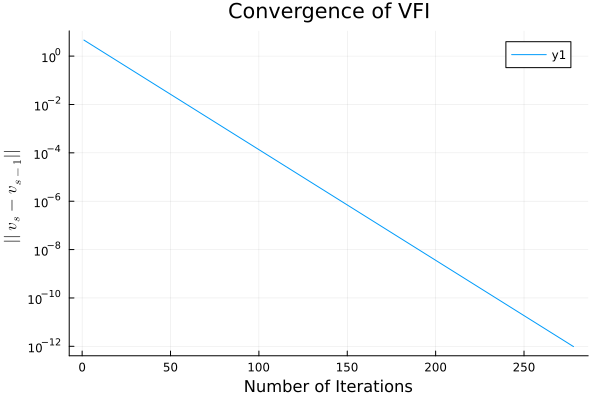

In [13]:
n = 1000
kgrid = LinRange(1e-4, 10, n)
V0 = zeros(n)
solution = solve!(p, kgrid, V0)


@unpack errors = solution 
plot(1:length(errors), errors, yscale = :log10, 
    title  = "Convergence of VFI",
    xlabel = "Number of Iterations",
    ylabel = raw"$||v_s - v_{s-1}||$",
    yticks = 10.0.^(0:-2:-12)
)

Let's try to add some policy function iteration steps, to see if that improves things...

Remember, when we do a policy iteration step, we will use the policy functions we calculated in our VFI step, and then apply them repeatedly.


In [15]:
function policy_step!(p, V, policy, kgrid, V0)
    @unpack α, A, β, δ = p

    for i in 1:length(kgrid)
        # Current capital and savings for tomorrow
        k  = kgrid[i]
        k′ = kgrid[policy[i]]
        
        # Current cash on hands, and consumption
        z  = A * k^α + (1-δ) * k
        c  = z - k′

        # Update value function
        V[i] = u(c) + β * V0[policy[i]]
    end
end

function solve_pfi!(p, kgrid, V0; tol = 1e-12, policy_steps = 0, maxiter = 1000)
    
    V0      = copy(V0)
    V       = similar(V0)
    Vs      = similar(V0)
    policy  = zeros(Int, size(V0))
    errors  = Float64[]  
    iter    = 0
    while true
        # Update our value function
        iter += 1
        # V0 ~ V_{s-1}(k)
        # V ~ V_{s}^0(k)
        update_bellman!(p, Vs, policy, kgrid, V0)  
        V .= Vs # this is redundant, but makes this code work if policy_steps = 0
        
        # Iterate on the policy rule 
        for i in 1:policy_steps
            # Vs ~ V_s^{j-1}
            # V  ~ V_s^j
            policy_step!(p, V, policy, kgrid, Vs)
            Vs .= V
        end

        # calculate and save the errors
        ϵ = absolute_error(V, V0)
        push!(errors, ϵ)
       
        # stop if we've converged
        ϵ < tol         && break
        iter > maxiter  && break 
        V0 .= V
    end

    return (; V, policy, iter, errors)

end


solve_pfi! (generic function with 1 method)

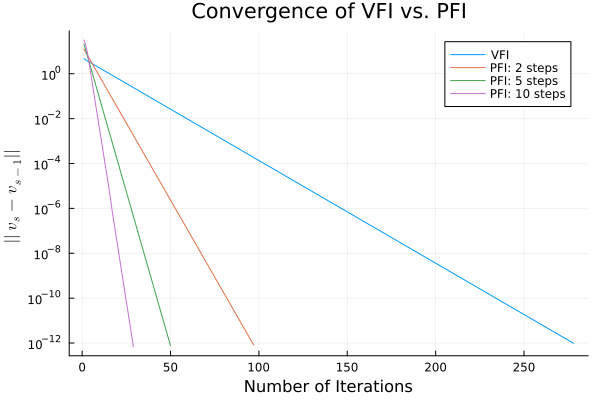

In [17]:
n = 1000

solution_vfi = solve_pfi!(p, LinRange(1e-4, 10, n), zeros(n))
@unpack errors = solution_vfi
plt = plot(1:length(errors), errors, yscale = :log10, 
    title  = "Convergence of VFI vs. PFI",
    label  = "VFI",
    xlabel = "Number of Iterations",
    ylabel = raw"$||v_s - v_{s-1}||$",
    yticks = 10.0.^(0:-2:-12)
)

# solution_vfi = solve_pfi!(p, LinRange(1e-4, 10, n), zeros(n); policy_steps = 100)

for k in (2,5,10)
    solution_pfi = solve_pfi!(p, LinRange(1e-4, 10, n), zeros(n), policy_steps = k)
    @unpack errors = solution_pfi
    plot!(1:length(errors), errors,
        label = "PFI: $k steps" 
    )
end
display(plt)

In [19]:
@info "Value Function Iteration"
@time solution_vfi = solve_pfi!(p, LinRange(1e-4, 10, n), zeros(n))
@info "PFI" k = 5
@time solution_vfi = solve_pfi!(p, LinRange(1e-4, 10, n), zeros(n), policy_steps = 5)

@info "PFI" k = 100
@time solution_vfi = solve_pfi!(p, LinRange(1e-4, 10, n), zeros(n), policy_steps = 100)

  5.434693 seconds (290 allocations: 2.201 MiB)


[ Info: Value Function Iteration
┌ Info: PFI
└   k = 5


  0.970088 seconds (61 allocations: 438.578 KiB)
  0.466019 seconds (26 allocations: 167.250 KiB)


┌ Info: PFI
└   k = 100


(V = [-46.061706863216735, -7.148700354096011, -6.216893711086472, -5.6411750140890735, -5.221900357567447, -4.8845890897737245, -4.602961481764046, -4.3598676858518015, -4.144724169096595, -3.9518733820854264  …  7.993245659670322, 7.997126203086168, 8.001003539466078, 8.004879406499134, 8.00875320989804, 8.012623675157005, 8.016492206646998, 8.020359188017892, 8.02422058096322, 8.028078857798862], policy = [1, 7, 11, 13, 15, 18, 20, 21, 23, 25  …  934, 935, 936, 936, 937, 938, 939, 940, 941, 942], iter = 16, errors = [46.06060574618427, 40.927115393801785, 5.974789976316332, 0.3294921651029714, 0.11565415195360673, 0.041184854616011624, 0.008432821343085872, 0.002493066604609684, 0.000867542533792065, 0.00023618620337129137, 5.819840757903538e-5, 3.208695574441478e-5, 1.7418573486693845e-5, 7.46322791922438e-6, 3.4291021275834055e-6, 0.0])

# Neoclassical Growth: Stochastic Productivity
Let's go back to the version we saw at the end of lecture, where productivity $A$ is a log-normal AR(1) process.
\begin{equation}
    \begin{aligned}
        v(k, A) =& 
        \max_{c, k'} \;\; 
            & u(c) + &\beta \mathbb E\left[ 
                v(k', A') \middle | A
                \right] \\
        & \text{s.t. }
            & c + k' &\leq A k^\alpha + (1-\delta) k  \\
            && \log(A') &= \rho \log(A) + \epsilon   \\
            && \epsilon &\sim N(0, \sigma)
    \end{aligned}
\end{equation} 
Let's code this up, using the method we discussed in class (discretizing the TFP process with Rouwenhorst's method)

Now let's solve it!

In [25]:
function solve_vfi2!(p, kgrid, V0; tol = 1e-12, maxiter = 1000, debug=false)
    @unpack Na, ρ, σ = p
    V0      = copy(V0)
    V       = zeros(size(V0))
    policy  = zeros(Int, size(V0))
    errors  = Float64[]  
    iter    = 0

    # Discretize the income process
    mc      = rouwenhorst(Na, ρ, σ)
    P       = mc.p'
    agrid   = mc.state_values
    
    grids   = (; kgrid, agrid)
    while true
        iter += 1 
        
        # Step 1: Calculate Expectations
        EV = V * P

        # Step 2: Update Bellman Equation
        update_bellman2!(p, V, policy, grids, EV)
        
        # Step 3: Check for convergence 
        ϵ = maximum(abs.(V - V0))
        push!(errors, ϵ)

        ϵ < tol         && break 
        iter >= maxiter && break
        V0 .= V
    end
    return (; V, policy, iter, errors, kgrid, agrid, P)
end

function update_bellman2!(p, V, policy, grids, EV)
    @unpack kgrid, agrid = grids 
    @unpack α, δ, β      = p 

    # Check all the dimensions are right
    length(kgrid) == size(V,1) || throw(error("capital grid size doesn't match V"))
    length(agrid) == size(V,2) || throw(error("TFP grid size doesn't match V"))
    size(EV)      == size(V)   || throw(error("EV and V aren't the same size"))
    
    # Loop over all the indices of V 
    for sub in CartesianIndices(V)
        # Unpack everything 
        ki, ai = sub[1], sub[2]
        k = kgrid[ki]
        A = exp(agrid[ai])
        
        # Cash on hands
        z  = A * k^α + (1-δ) * k 
        k′ = kgrid
        c  = z .- k′
        
        # Do a vectorized grid search 
        # Note: the macro views makes this run a bit faster but otherwise doesn't change anything
        vmax, pol = @views findmax(u.(c) .+ β .* EV[:, ai])
        
        # Store the max values and policies
        V[sub]      = vmax
        policy[sub] = pol
    end
    return 
end


update_bellman2! (generic function with 1 method)

In [27]:
## Run the code 
# Setup parameters
Nk = 100
Na = 30
p  = (; β = 0.9, δ = 0.1, α = 0.5, ρ = 0.7, σ = 0.1, Na)

V0     = zeros(Nk, Na)
kgrid  = LinRange(1e-4, 50, Nk)

# Solve the model 
@time solution = solve_vfi2!(p, kgrid, V0)
@unpack V, policy, errors = solution 

  6.740031 seconds (3.41 M allocations: 906.843 MiB, 9.04% gc time, 82.39% compilation time)


(V = [-48.102509777050734 -47.96172086057842 … -44.1627672880493 -44.022123311144654; -4.897279384855084 -4.706918903074508 … 2.7879294439174487 3.1391229191253167; … ; 13.816761278175917 13.897825372213015 … 17.02142023276401 17.180313256187848; 13.87260485198118 13.953654112668467 … 17.068558917514785 17.22716104268813], policy = [1 1 … 1 1; 2 2 … 4 4; … ; 79 79 … 95 96; 80 80 … 96 97], iter = 278, errors = [5.36137199329617, 4.621254359602552, 4.030661420762888, 3.546675953584497, 3.1410352051262613, 2.7948210612825832, 2.495110292915985, 2.232855644373359, 2.0015417880173736, 1.7963298668178105  …  2.5295321393059567e-12, 2.2737367544323206e-12, 2.0534685063466895e-12, 1.8474111129762605e-12, 1.6626700016786344e-12, 1.4921397450962104e-12, 1.3500311979441904e-12, 1.2150280781497713e-12, 1.0942358130705543e-12, 9.876544027065393e-13], kgrid = LinRange{Float64}(0.0001, 50.0, 100), agrid = -0.7540739028638985:0.052005096749234384:0.7540739028638985, P = [0.008977364229164094 0.0015842

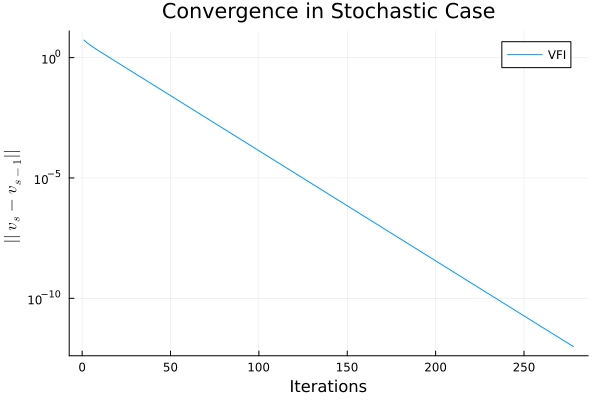

In [29]:
plot(1:length(errors), errors, 
    yscale = :log10,
    title  = "Convergence in Stochastic Case",
    xlabel = "Iterations",
    ylabel = raw"$||v_s - v_{s-1}||$",
    label  = "VFI",
    # yticks = 10.0.^(0:-2:-10)
)

## Policy Functions 
Let's plot the optimal policy functions.  That is, we want to show 
$c(k, A)$ and $k'(k,A)$ that solve our maximization problem.

Note that since we now have a two dimensional state space, we will need to plot these policy functions 
holding one of the states constant.  (In principle, you can do 2d surface plots, but I find they're not very helpful).  So, we'll plot $c(k, A_i)$ for several different fixed TFP values $A_i$ 

In [33]:
@unpack α, δ         = p
@unpack kgrid, agrid = solution
k′ = kgrid[solution.policy]
z  = exp.(agrid') .* kgrid.^α .+ (1-δ) .* kgrid
c  = z .- k′

# Consumption/investment share 
cs = c./z
ks = k′./z

## First let's plot consumption policy for a variety of TFP values 
AVals = [1, 10, 20, 30]
p1 = plot(legend=:outerbottom, legend_column = -1)
for ai in AVals
    plot!(kgrid, c[:, ai], label = format("A = {:.2f}", exp(agrid[ai])))
end
title!("Consumption Policy")
ylabel!(raw"$c(k)$")
xlabel!(raw"$k$")

## Next let's plot investment policy for the same TFP values
p2 = plot(legend=:outerbottom, legend_column = -1)
for ai in AVals
    plot!(kgrid, k′[:, ai], label = format("A = {:.2f}", exp(agrid[ai])))
end
title!("Investment Policy")
ylabel!(raw"$k'(k)$")
xlabel!(raw"$k$")

plt = plot(p1, p2, size = (800, 400), layout = (1,2))

LoadError: BoundsError: attempt to access 100×30 Matrix{Float64} at index [1:100, 100]

Note: I had to drive $N_k$ up to 600 to make these policy functions look
relatively smooth (and even now, if you look closely you can see the jagged
edges), and that make our solution take almost 30 seconds.  Try it with 100.
What does it look like?  Does it matter if the policy functions are noisy?

Try running this code with an upper bound on $k$ that is smaller.  What does it
look like if you use $\overline k = 10$?  Is that a problem for us?


(100,)

---

**Note:** this tutorial notebook is written in **Julia** (outputs are embedded, so you can read everything here). To run it yourself, install [Julia](https://julialang.org/downloads/) and IJulia — or focus on the logic, which carries over to Python directly. Work through [PS7](../psets/PS7.pdf) with your group.

*Next week: model estimation.*